# APM Chart (10-min) - Analyse Exploratoire des Données (EDA)

## Description du Dataset
Ce notebook analyse le fichier **APM_Chart_10min_ML.csv**.

**Caractéristiques principales:**
- **26,281 lignes** × **26 colonnes**
- Données temporelles à fréquence **10 minutes**
- Variables: températures stator, puissance, tension, fréquence

## 1. Import des Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn     as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Librairies importées avec succès!')

Librairies importées avec succès!


## 2. Chargement et Aperçu des Données

In [2]:
df = pd.read_csv('../LAST_DATA/APM_Chart_10min_ML.csv')

print('=' * 80)
print('APERÇU DES DONNÉES')
print('=' * 80)
df.head(10)

APERÇU DES DONNÉES


,Datetime,MODE_TAG_1,REACTIVE_LOAD,SPEED_CTRL_pct,STATOR_PHASE_A_WINDING_TEMP_1_degC,STATOR_PHASE_A_WINDING_TEMP_2_degC,STATOR_PHASE_A_WINDING_TEMP_3_degC,STATOR_PHASE_B_WINDING_TEMP_1_degC,STATOR_PHASE_B_WINDING_TEMP_2_degC,STATOR_PHASE_B_WINDING_TEMP_3_degC,STATOR_PHASE_C_WINDING_TEMP_1_degC,STATOR_PHASE_C_WINDING_TEMP_2_degC,STATOR_PHASE_C_WINDING_TEMP_3_degC,TERMINAL_VOLTAGE_kV,FREQUENCY_Hz,ENCLOSED_HOT_AIR_TEMP_2_degC,ENCLOSED_HOT_AIR_TEMP_1_degC,ENCLOSED_COLD_AIR_TEMP_2_degC,ENCLOSED_COLD_AIR_TEMP_1_degC,AMBIENT_AIR_TEMP_C,Year,Month,Day,Hour,Minute,DayOfWeek,Quarter,SPEED_rpm,P_ACTIVE_MW,P_REACTIVE_MVAR,P_APPARENT_MVA,POWER_FACTOR,TEMP_PHASE_A_MEAN_degC,TEMP_PHASE_B_MEAN_degC,TEMP_PHASE_C_MEAN_degC,TEMP_STATOR_MEAN_degC,TEMP_STATOR_MAX_degC,TEMP_PHASE_IMBALANCE_degC,TEMP_HOT_AIR_MEAN_degC,TEMP_COLD_AIR_MEAN_degC,COOLING_DELTA_T_degC,TEMP_RISE_ABOVE_AMBIENT_degC
0,2025-02-02 11:58:34,-0.14,-0.49,0.00,31.01,31.20,34.98,34.83,29.51,31.11,34.93,31.82,34.20,0.00,0.00,27.27,27.56,31.91,31.91,10.97,2025,2,2,11,58,6,1,0.00,-0.14,-0.49,0.51,-0.27,32.40,31.82,33.65,32.62,34.98,1.83,27.41,31.91,-4.49,21.65
1,2025-02-03 01:08:34,-0.15,-0.48,0.00,30.98,31.22,35.02,34.81,29.51,31.11,34.93,31.84,34.13,0.00,0.00,26.87,27.11,31.46,31.46,10.54,2025,2,3,1,8,0,1,0.00,-0.15,-0.48,0.51,-0.31,32.41,31.81,33.63,32.62,35.02,1.82,26.99,31.46,-4.47,22.08
2,2025-02-03 01:18:34,-0.15,-0.48,0.00,30.43,30.91,34.35,34.01,29.36,30.39,34.21,31.55,33.49,0.00,0.00,27.14,26.90,29.87,29.87,18.70,2025,2,3,1,18,0,1,0.00,-0.15,-0.48,0.51,-0.29,31.89,31.26,33.08,32.08,34.35,1.83,27.02,29.87,-2.85,13.37
3,2025-02-03 01:28:34,-0.14,-0.49,0.00,30.45,30.91,34.29,34.00,29.37,30.39,34.16,31.54,33.46,0.00,0.00,27.32,27.02,29.88,29.88,19.00,2025,2,3,1,28,0,1,0.00,-0.14,-0.49,0.51,-0.27,31.89,31.25,33.05,32.06,34.29,1.80,27.17,29.88,-2.72,13.06
4,2025-02-03 01:38:34,-0.14,-0.46,0.00,30.44,30.91,34.29,34.01,29.36,30.38,34.16,31.53,33.48,0.00,0.00,27.48,27.17,29.93,29.93,18.86,2025,2,3,1,38,0,1,0.00,-0.14,-0.46,0.48,-0.28,31.88,31.25,33.05,32.06,34.29,1.80,27.32,29.93,-2.61,13.21
5,2025-02-03 01:48:34,-0.15,-0.49,0.00,30.44,30.90,34.30,34.00,29.35,30.37,34.17,31.52,33.47,0.00,0.00,27.65,27.28,30.06,30.06,18.67,2025,2,3,1,48,0,1,0.00,-0.15,-0.49,0.51,-0.30,31.88,31.24,33.06,32.06,34.30,1.81,27.47,30.06,-2.59,13.39
6,2025-02-03 01:58:34,-0.16,-0.47,0.00,30.43,30.89,34.23,34.01,29.35,30.40,34.11,31.53,33.45,0.00,0.00,27.69,27.36,30.07,30.07,18.76,2025,2,3,1,58,0,1,0.00,-0.16,-0.47,0.50,-0.31,31.85,31.26,33.03,32.05,34.23,1.78,27.52,30.07,-2.55,13.29
7,2025-02-03 02:08:34,-0.15,-0.47,0.00,31.01,31.22,34.98,34.75,29.51,31.06,34.88,31.85,34.17,0.00,0.00,26.68,26.96,31.28,31.28,10.17,2025,2,3,2,8,0,1,0.00,-0.15,-0.47,0.50,-0.31,32.40,31.77,33.63,32.60,34.98,1.86,26.82,31.28,-4.46,22.43
8,2025-02-03 02:18:34,-0.14,-0.50,0.00,30.45,30.88,34.19,34.01,29.35,30.43,34.11,31.52,33.47,0.00,0.00,27.82,27.60,30.25,30.25,18.80,2025,2,3,2,18,0,1,0.00,-0.14,-0.50,0.52,-0.27,31.84,31.26,33.03,32.04,34.19,1.77,27.71,30.25,-2.54,13.24
9,2025-02-03 02:28:34,-0.15,-0.46,0.00,30.42,30.88,34.23,34.04,29.34,30.41,34.14,31.50,33.46,0.00,0.00,27.83,27.64,30.29,30.29,18.63,2025,2,3,2,28,0,1,0.00,-0.15,-0.46,0.49,-0.31,31.84,31.27,33.03,32.05,34.23,1.77,27.73,30.29,-2.55,13.42


In [3]:
print('\nINFORMATIONS SUR LE DATASET:')
df.info()


INFORMATIONS SUR LE DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 26281 entries, 0 to 26280
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Datetime                            26281 non-null  str    
 1   MODE_TAG_1                          26281 non-null  float64
 2   REACTIVE_LOAD                       26281 non-null  float64
 3   SPEED_CTRL_pct                      26281 non-null  float64
 4   STATOR_PHASE_A_WINDING_TEMP_1_degC  26281 non-null  float64
 5   STATOR_PHASE_A_WINDING_TEMP_2_degC  26281 non-null  float64
 6   STATOR_PHASE_A_WINDING_TEMP_3_degC  26281 non-null  float64
 7   STATOR_PHASE_B_WINDING_TEMP_1_degC  26281 non-null  float64
 8   STATOR_PHASE_B_WINDING_TEMP_2_degC  26281 non-null  float64
 9   STATOR_PHASE_B_WINDING_TEMP_3_degC  26281 non-null  float64
 10  STATOR_PHASE_C_WINDING_TEMP_1_degC  26281 non-null  float64
 11  STATOR_PHASE_C_WINDING

## 3. Dimensions et Types de Colonnes

In [4]:
print('=' * 80)
print('DIMENSIONS')
print('=' * 80)
print(f'Nombre de lignes: {df.shape[0]:,}')
print(f'Nombre de colonnes: {df.shape[1]}')
print(f'\nMémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print('\n' + '=' * 80)
print('COLONNES')
print('=' * 80)
for i, col in enumerate(df.columns):
    print(f'{i+1:2}. {col} ({df[col].dtype})')

DIMENSIONS
Nombre de lignes: 26,281
Nombre de colonnes: 42

Mémoire: 8.90 MB

COLONNES
 1. Datetime (str)
 2. MODE_TAG_1 (float64)
 3. REACTIVE_LOAD (float64)
 4. SPEED_CTRL_pct (float64)
 5. STATOR_PHASE_A_WINDING_TEMP_1_degC (float64)
 6. STATOR_PHASE_A_WINDING_TEMP_2_degC (float64)
 7. STATOR_PHASE_A_WINDING_TEMP_3_degC (float64)
 8. STATOR_PHASE_B_WINDING_TEMP_1_degC (float64)
 9. STATOR_PHASE_B_WINDING_TEMP_2_degC (float64)
10. STATOR_PHASE_B_WINDING_TEMP_3_degC (float64)
11. STATOR_PHASE_C_WINDING_TEMP_1_degC (float64)
12. STATOR_PHASE_C_WINDING_TEMP_2_degC (float64)
13. STATOR_PHASE_C_WINDING_TEMP_3_degC (float64)
14. TERMINAL_VOLTAGE_kV (float64)
15. FREQUENCY_Hz (float64)
16. ENCLOSED_HOT_AIR_TEMP_2_degC (float64)
17. ENCLOSED_HOT_AIR_TEMP_1_degC (float64)
18. ENCLOSED_COLD_AIR_TEMP_2_degC (float64)
19. ENCLOSED_COLD_AIR_TEMP_1_degC (float64)
20. AMBIENT_AIR_TEMP_C (float64)
21. Year (int64)
22. Month (int64)
23. Day (int64)
24. Hour (int64)
25. Minute (int64)
26. DayOfWeek (i

## 4. Résumé Statistique

In [5]:
print('STATISTIQUES DESCRIPTIVES')
df.describe().T

STATISTIQUES DESCRIPTIVES


,count,mean,std,min,25%,50%,75%,max
MODE_TAG_1,26281.00,53.45,52.30,-0.21,-0.16,86.75,106.89,123.55
REACTIVE_LOAD,26281.00,3.28,16.29,-46.90,-0.48,-0.44,10.84,57.97
SPEED_CTRL_pct,26281.00,52.13,49.24,0.00,0.00,99.88,100.01,100.51
STATOR_PHASE_A_WINDING_TEMP_1_degC,26281.00,60.75,24.79,0.00,35.40,71.27,85.79,96.06
STATOR_PHASE_A_WINDING_TEMP_2_degC,26281.00,66.25,30.07,0.00,35.63,77.44,96.94,112.75
STATOR_PHASE_A_WINDING_TEMP_3_degC,26281.00,57.93,19.64,0.00,38.46,64.85,77.85,87.18
STATOR_PHASE_B_WINDING_TEMP_1_degC,26281.00,59.88,21.92,0.00,38.10,67.40,82.15,92.59
STATOR_PHASE_B_WINDING_TEMP_2_degC,26281.00,65.29,30.12,0.00,34.05,76.87,95.88,111.19
STATOR_PHASE_B_WINDING_TEMP_3_degC,26281.00,59.00,23.00,0.00,35.56,67.78,82.33,91.71
STATOR_PHASE_C_WINDING_TEMP_1_degC,26281.00,57.74,19.57,0.00,38.45,63.73,77.61,87.22


## 5. Analyse des Valeurs Manquantes

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('VALEURS MANQUANTES:')
missing_df = pd.DataFrame({'Manquantes': missing, '%': missing_pct})
print(missing_df)
print(f'\nTotal: {missing.sum()} valeurs manquantes')

VALEURS MANQUANTES:
                                    Manquantes    %
Datetime                                     0 0.00
MODE_TAG_1                                   0 0.00
REACTIVE_LOAD                                0 0.00
SPEED_CTRL_pct                               0 0.00
STATOR_PHASE_A_WINDING_TEMP_1_degC           0 0.00
STATOR_PHASE_A_WINDING_TEMP_2_degC           0 0.00
STATOR_PHASE_A_WINDING_TEMP_3_degC           0 0.00
STATOR_PHASE_B_WINDING_TEMP_1_degC           0 0.00
STATOR_PHASE_B_WINDING_TEMP_2_degC           0 0.00
STATOR_PHASE_B_WINDING_TEMP_3_degC           0 0.00
STATOR_PHASE_C_WINDING_TEMP_1_degC           0 0.00
STATOR_PHASE_C_WINDING_TEMP_2_degC           0 0.00
STATOR_PHASE_C_WINDING_TEMP_3_degC           0 0.00
TERMINAL_VOLTAGE_kV                          0 0.00
FREQUENCY_Hz                                 0 0.00
ENCLOSED_HOT_AIR_TEMP_2_degC                 0 0.00
ENCLOSED_HOT_AIR_TEMP_1_degC                 0 0.00
ENCLOSED_COLD_AIR_TEMP_2_degC               

## 6. Distribution des Variables Principales

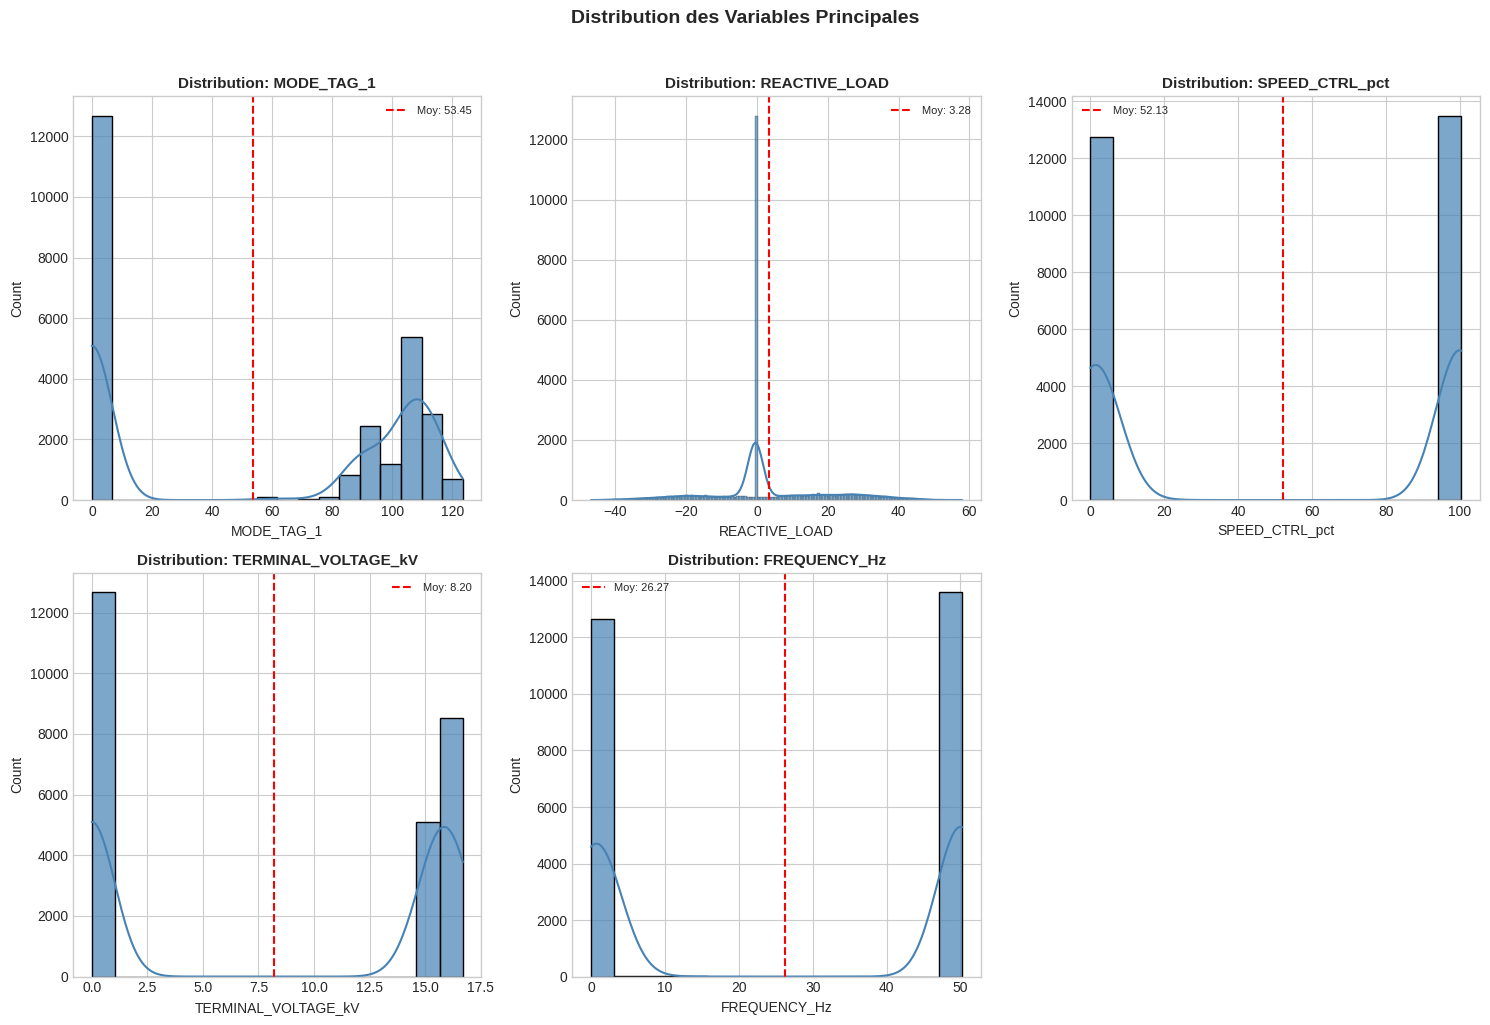

In [8]:
main_vars = ['MODE_TAG_1', 'REACTIVE_LOAD', 'SPEED_CTRL_pct', 'TERMINAL_VOLTAGE_kV', 'FREQUENCY_Hz']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(main_vars):
    ax = axes[i]
    sns.histplot(df[var], kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'Distribution: {var}', fontsize=11, fontweight='bold')
    ax.axvline(df[var].mean(), color='red', linestyle='--', label=f'Moy: {df[var].mean():.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution des Variables Principales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

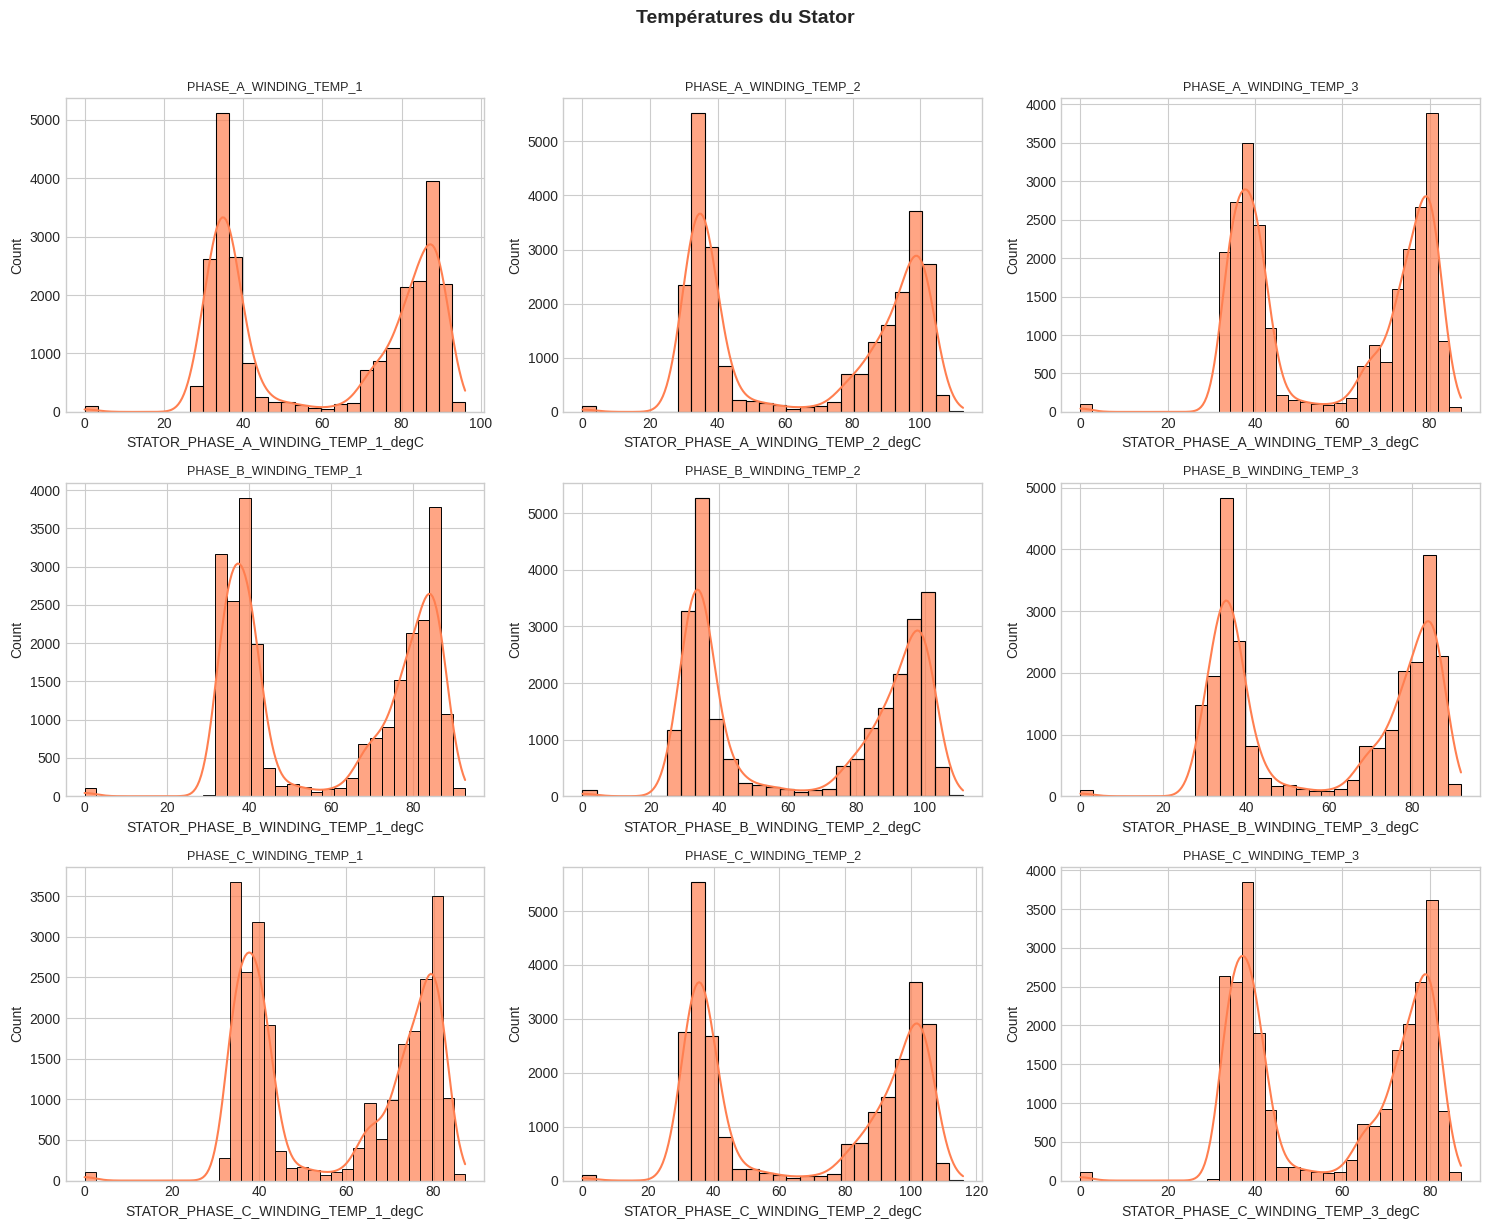

In [10]:
# Températures du stator
temp_cols = [col for col in df.columns if 'STATOR' in col and 'TEMP' in col]
temp_cols = temp_cols[:9]  # Limiter à 9 pour 3x3 grid

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(temp_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='coral', alpha=0.7)
    ax.set_title(col.replace('STATOR_', '').replace('_degC', ''), fontsize=9)

plt.suptitle('Températures du Stator', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Matrice de Corrélation

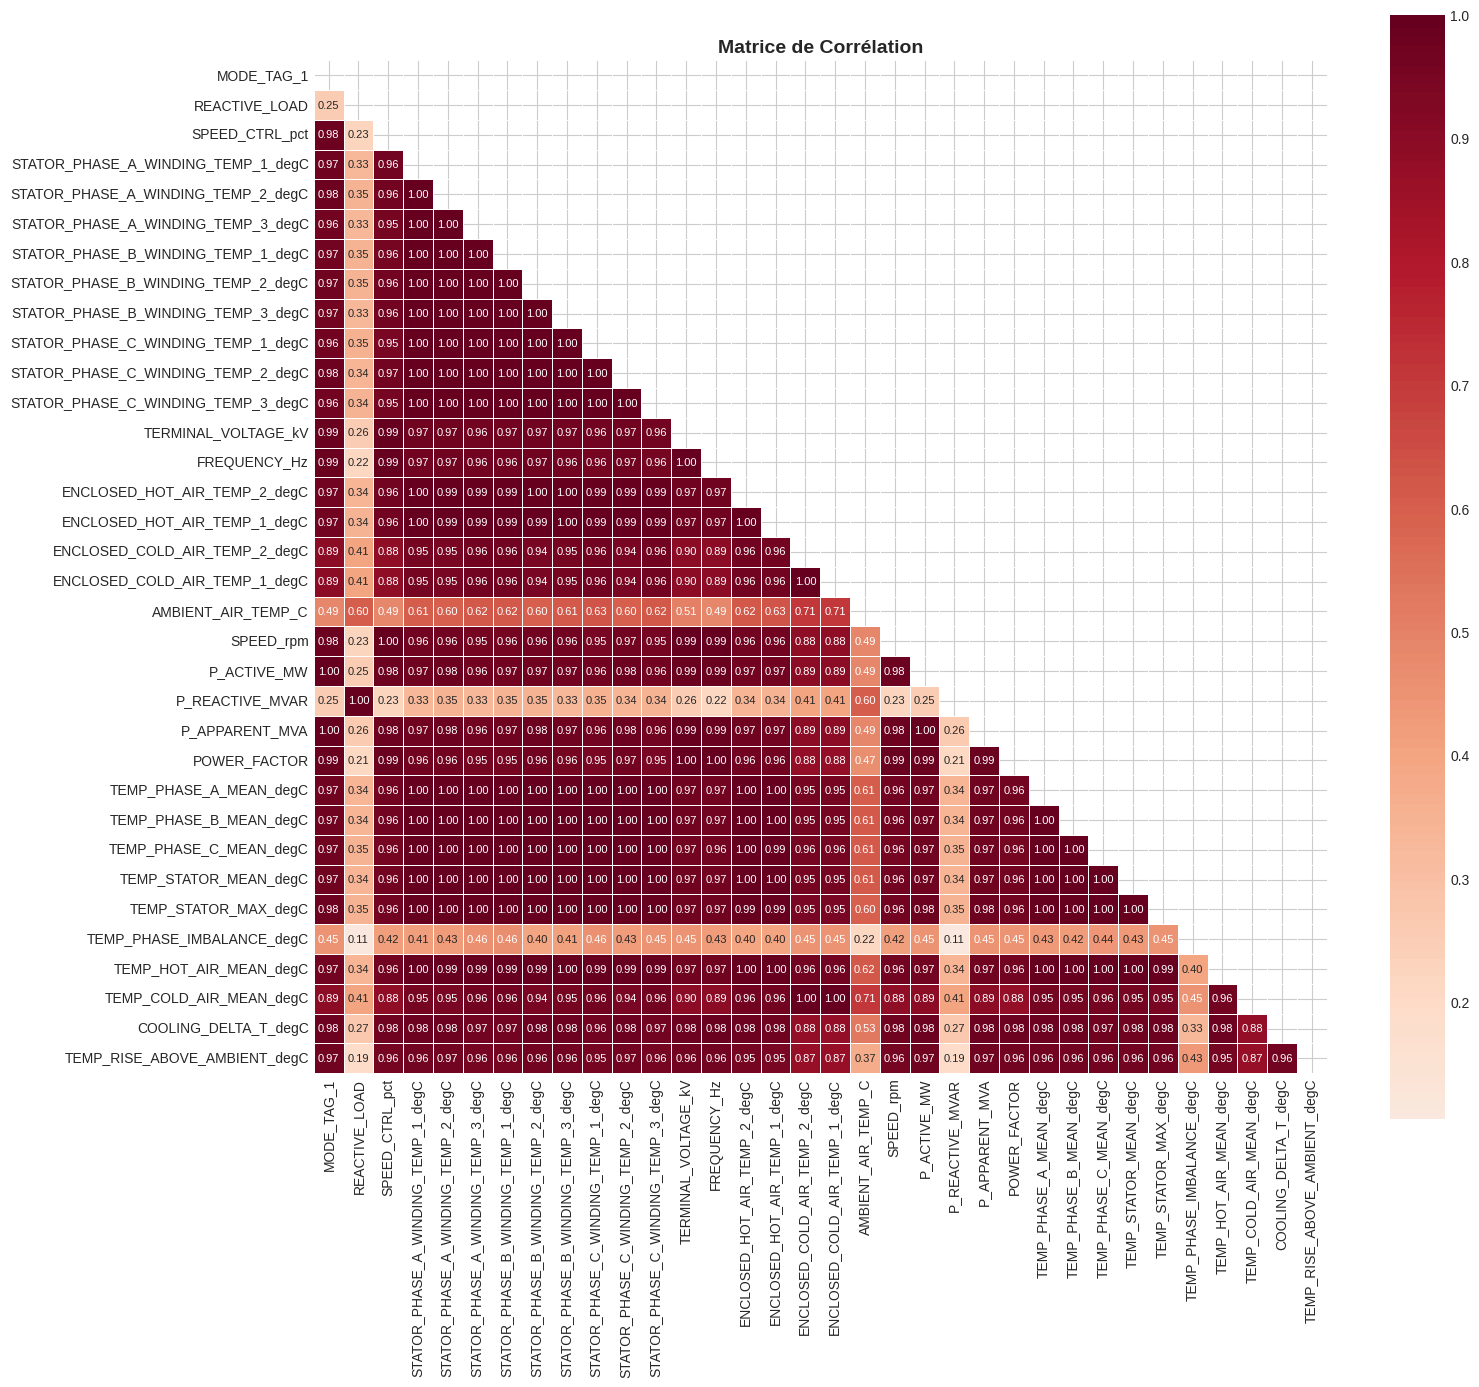

In [11]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col not in ['Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'Quarter']]

corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualisation Temporelle

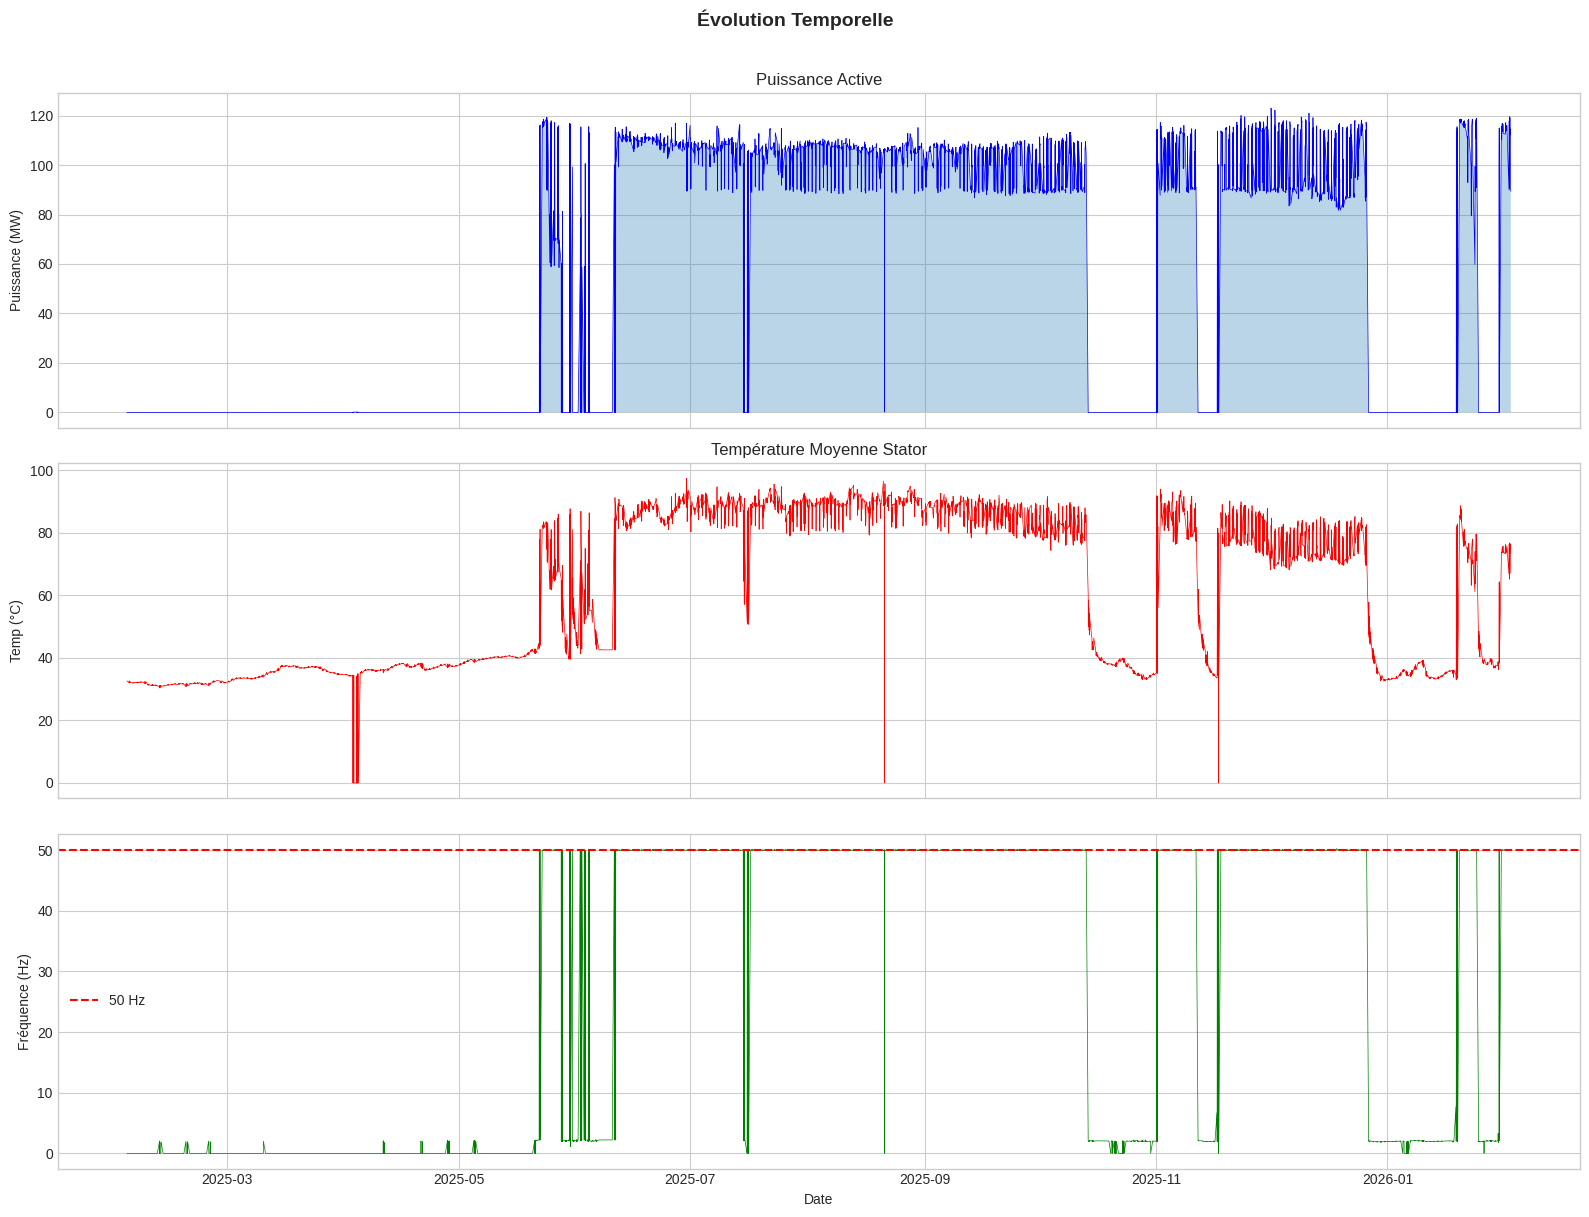

In [12]:
if all(col in df.columns for col in ['Year', 'Month', 'Day', 'Hour', 'Minute']):
    df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
    
    # Sous-échantillonner pour visualisation
    step = max(1, len(df) // 5000)
    sample = df.iloc[::step].copy()
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    
    axes[0].plot(sample['DateTime'], sample['MODE_TAG_1'], color='blue', linewidth=0.5)
    axes[0].set_ylabel('Puissance (MW)')
    axes[0].set_title('Puissance Active')
    axes[0].fill_between(sample['DateTime'], sample['MODE_TAG_1'], alpha=0.3)
    
    temp_mean = sample[temp_cols].mean(axis=1)
    axes[1].plot(sample['DateTime'], temp_mean, color='red', linewidth=0.5)
    axes[1].set_ylabel('Temp (°C)')
    axes[1].set_title('Température Moyenne Stator')
    
    axes[2].plot(sample['DateTime'], sample['FREQUENCY_Hz'], color='green', linewidth=0.5)
    axes[2].axhline(50, color='red', linestyle='--', label='50 Hz')
    axes[2].set_ylabel('Fréquence (Hz)')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    
    plt.suptitle('Évolution Temporelle', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

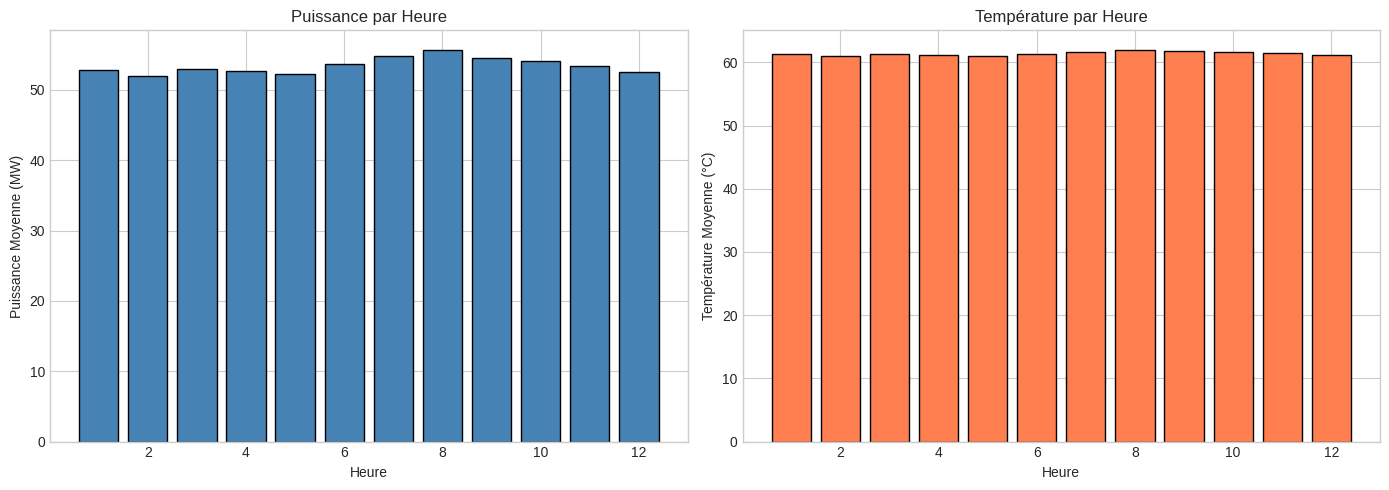

In [13]:
# Analyse par heure
if 'Hour' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    hourly_power = df.groupby('Hour')['MODE_TAG_1'].mean()
    axes[0].bar(hourly_power.index, hourly_power.values, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Heure')
    axes[0].set_ylabel('Puissance Moyenne (MW)')
    axes[0].set_title('Puissance par Heure')
    
    hourly_temp = df.groupby('Hour')[temp_cols].mean().mean(axis=1)
    axes[1].bar(hourly_temp.index, hourly_temp.values, color='coral', edgecolor='black')
    axes[1].set_xlabel('Heure')
    axes[1].set_ylabel('Température Moyenne (°C)')
    axes[1].set_title('Température par Heure')
    
    plt.tight_layout()
    plt.show()

## 9. Détection des Outliers (Box Plots)

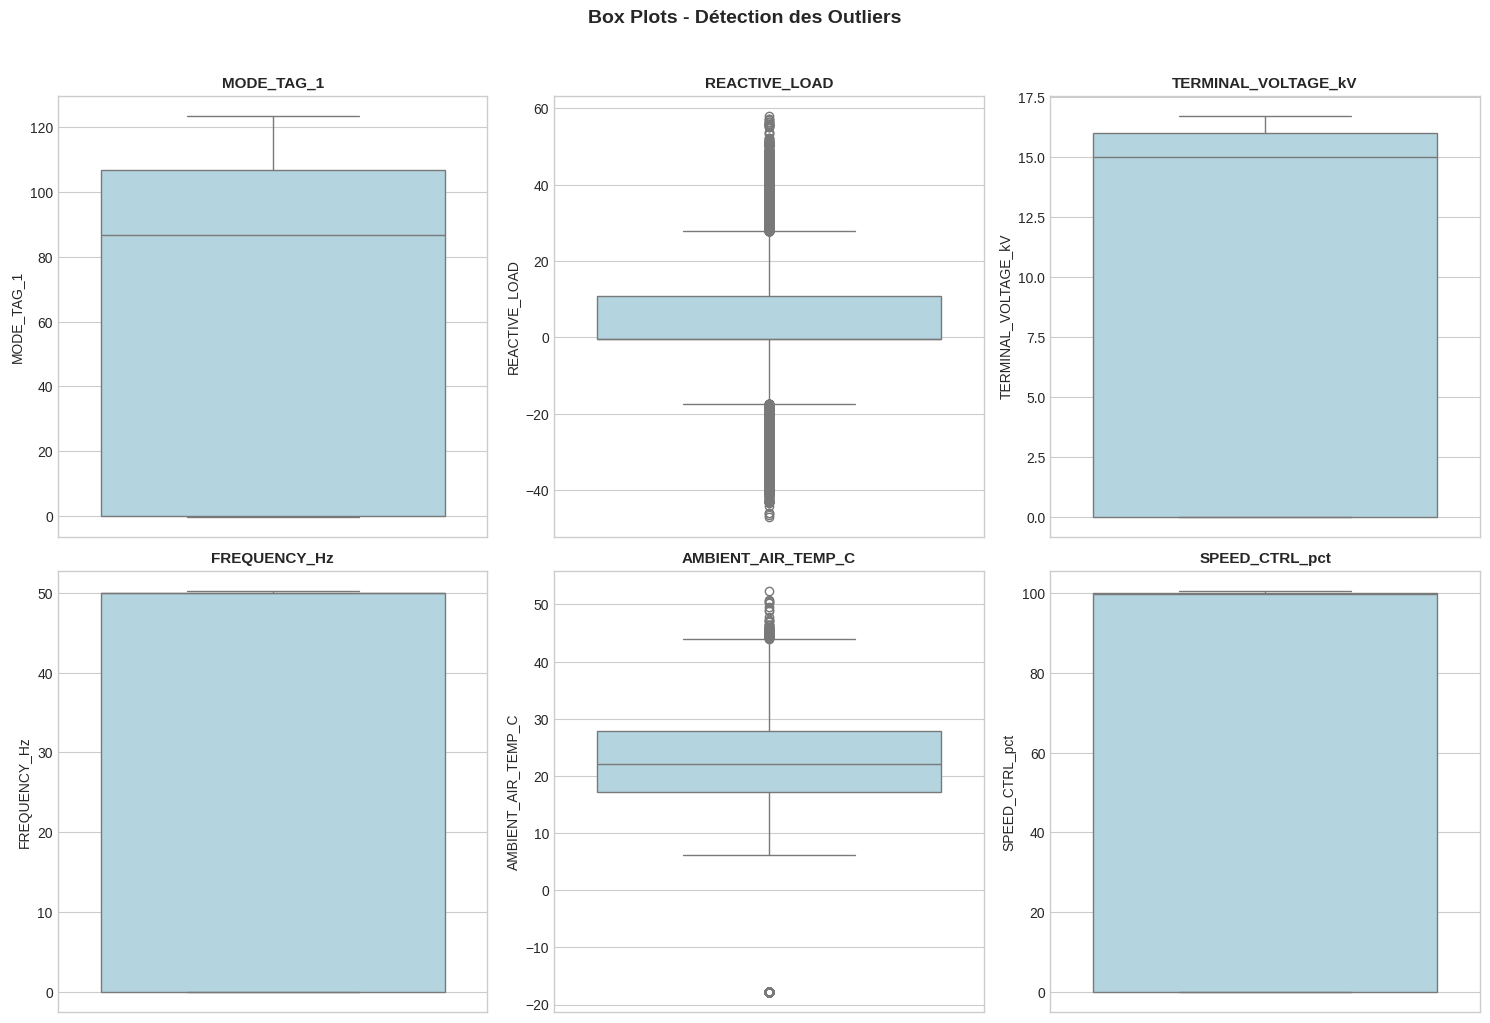

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

boxplot_vars = ['MODE_TAG_1', 'REACTIVE_LOAD', 'TERMINAL_VOLTAGE_kV', 
                'FREQUENCY_Hz', 'AMBIENT_AIR_TEMP_C', 'SPEED_CTRL_pct']

for i, var in enumerate(boxplot_vars):
    sns.boxplot(y=df[var], ax=axes[i], color='lightblue')
    axes[i].set_title(var, fontsize=11, fontweight='bold')

plt.suptitle('Box Plots - Détection des Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

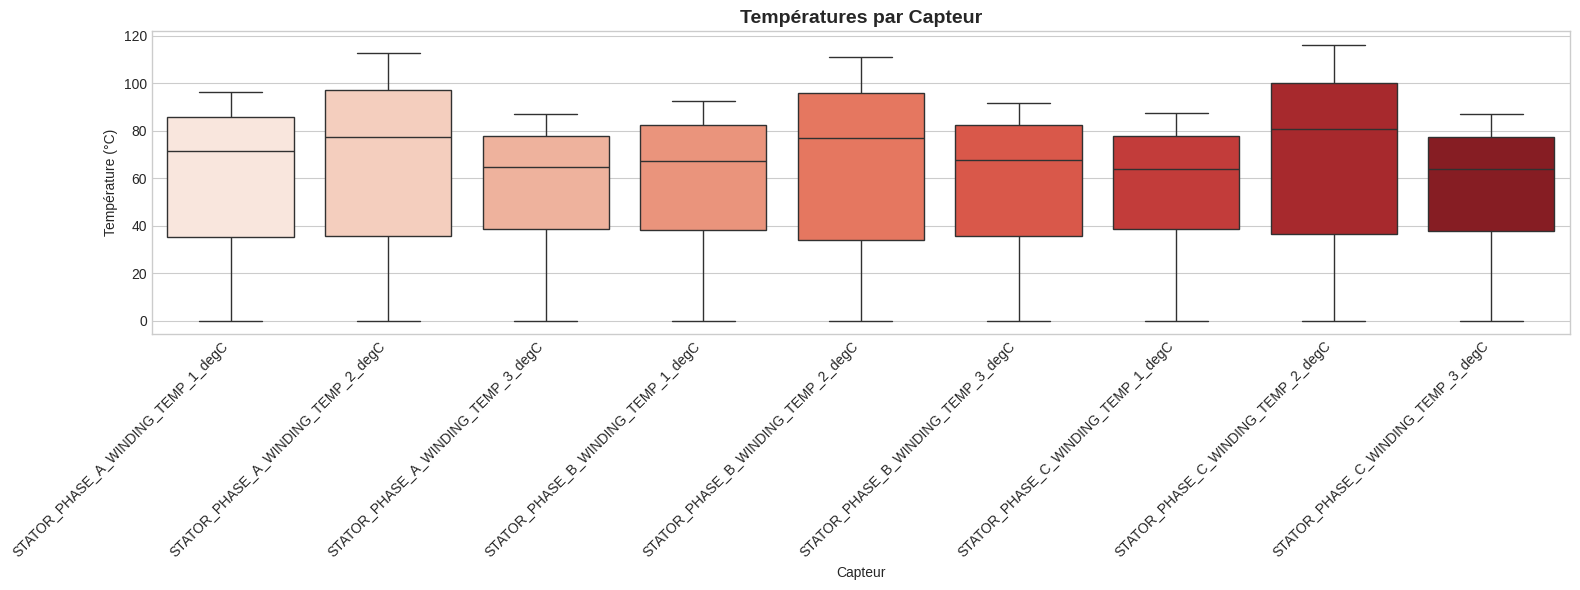

In [16]:
# Box plots des températures
temp_data = df[temp_cols].melt(var_name='Capteur', value_name='Température')

plt.figure(figsize=(16, 6))
sns.boxplot(data=temp_data, x='Capteur', y='Température', palette='Reds')
plt.xticks(rotation=45, ha='right')
plt.title('Températures par Capteur', fontsize=14, fontweight='bold')
plt.ylabel('Température (°C)')
plt.tight_layout()
plt.show()

## 10. Relations entre Variables

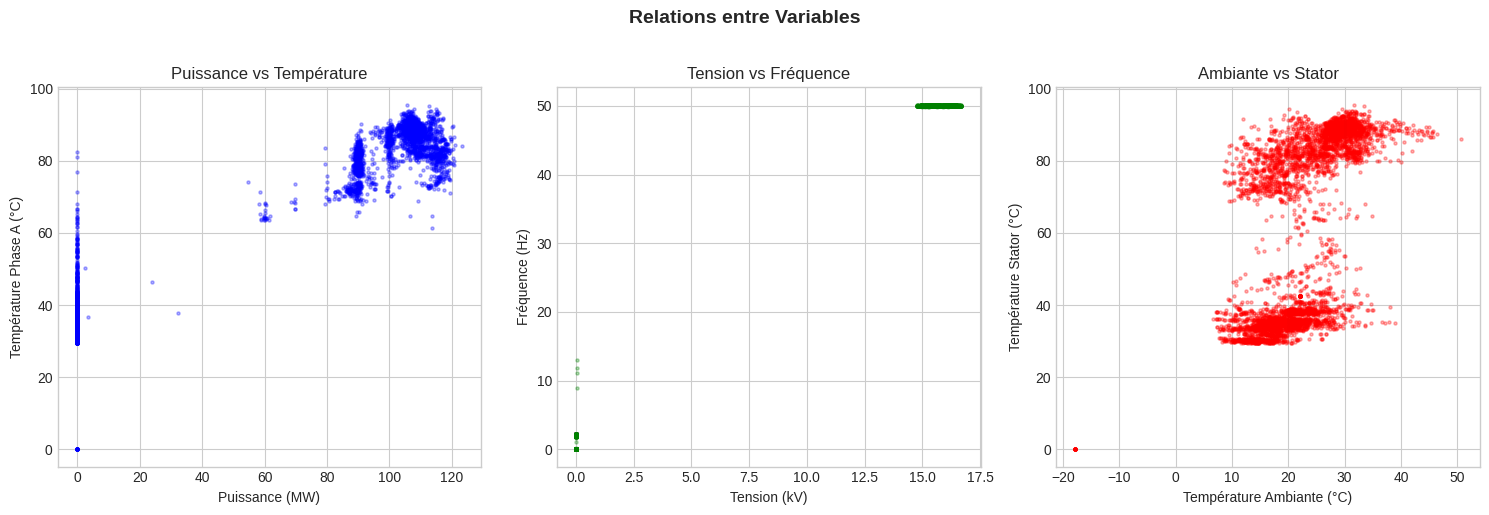

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sample = df.sample(n=min(5000, len(df)), random_state=42)

# Puissance vs Température
axes[0].scatter(sample['MODE_TAG_1'], sample['STATOR_PHASE_A_WINDING_TEMP_1_degC'], 
                alpha=0.3, s=5, c='blue')
axes[0].set_xlabel('Puissance (MW)')
axes[0].set_ylabel('Température Phase A (°C)')
axes[0].set_title('Puissance vs Température')

# Tension vs Fréquence
axes[1].scatter(sample['TERMINAL_VOLTAGE_kV'], sample['FREQUENCY_Hz'], 
                alpha=0.3, s=5, c='green')
axes[1].set_xlabel('Tension (kV)')
axes[1].set_ylabel('Fréquence (Hz)')
axes[1].set_title('Tension vs Fréquence')

# Température ambiante vs Stator
axes[2].scatter(sample['AMBIENT_AIR_TEMP_C'], sample['STATOR_PHASE_A_WINDING_TEMP_1_degC'], 
                alpha=0.3, s=5, c='red')
axes[2].set_xlabel('Température Ambiante (°C)')
axes[2].set_ylabel('Température Stator (°C)')
axes[2].set_title('Ambiante vs Stator')

plt.suptitle('Relations entre Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

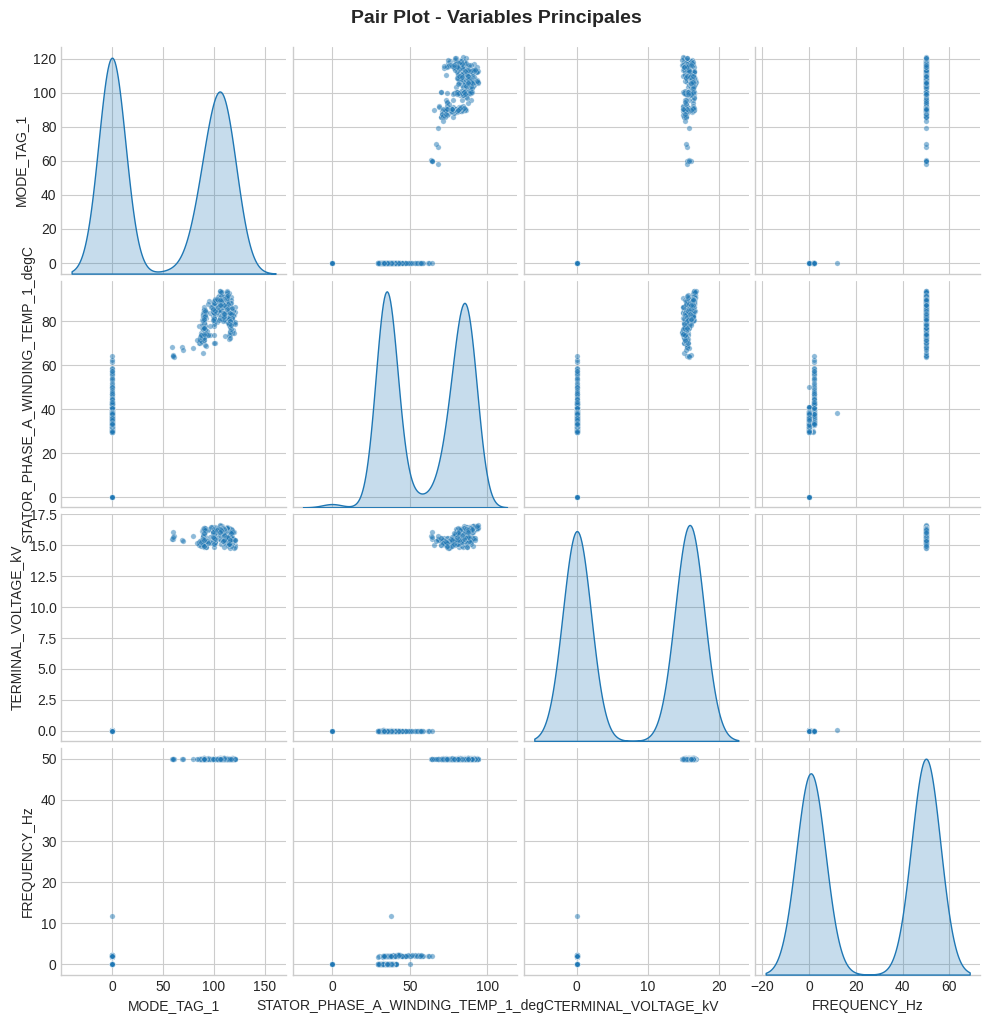

In [18]:
# Pair plot
key_vars = ['MODE_TAG_1', 'STATOR_PHASE_A_WINDING_TEMP_1_degC', 'TERMINAL_VOLTAGE_kV', 'FREQUENCY_Hz']
sample_small = df[key_vars].sample(n=min(1000, len(df)), random_state=42)

g = sns.pairplot(sample_small, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
g.fig.suptitle('Pair Plot - Variables Principales', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 11. Conclusions

### Résumé:
- **Qualité des données**: Pas de valeurs manquantes
- **Puissance active**: 0-124 MW
- **Températures stator**: ~60-115°C
- **Fréquence**: ~50 Hz (nominal)
- **Corrélations fortes** entre températures des phases et avec la puissance